In [3]:
%matplotlib inline
import numpy as np
import pandas as pd
from pylab import *
import matplotlib
#mport plplot
#rom scipy import stats
#from io import StringIO
print(pd.__version__)
#AttributeError: 'Series' object has no attribute 'to_numpy'
import re

import math
import astropy as astro
import scipy.ndimage as spimage
from astropy.io import fits, ascii
from astropy.table import Table, join,QTable
from astropy.cosmology import WMAP9 as cosmo
import matplotlib as mpl
#from numpy import std as biweight_midvariance
import matplotlib.cm as cm

from scipy import optimize
from scipy.stats import gaussian_kde
from matplotlib import colors
#mport scipy.ndimage as ndimage
from collections import Counter
from matplotlib.legend import Legend
import matplotlib.patches as patches
from matplotlib import pyplot
#rom mpl_toolkits.axes_grid1 import make_axes_locatable
#
#
#
import extinction


#
# seaborn
#
#mport pandas.util.testing as tm
import seaborn as sns

#
# Jorge
#

from sel2dhist_xy import sel2dhist_xy


#
# 3D plots!
#
import numpy as np
import scipy.linalg
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.pyplot as plt

#biweight_midvariance


import warnings
warnings.simplefilter("ignore")

#
# my_utils
#
from my_utils import *

#
#
#
from ndtest import *
from sklearn.decomposition import PCA

#
#
#
from scipy.optimize import leastsq, fmin
import matplotlib.animation as animation

#
# Carlos Color map
#
from cmaps_CLC import vel_map

from scipy.spatial import KDTree


import collections

import scipy.stats as st

import matplotlib.image as mpimg


2.3.3
2.3.3


In [4]:
def rebin(a, shape):
    sh = shape[0],a.shape[0]//shape[0],shape[1],a.shape[1]//shape[1]
    return a.reshape(sh).mean(-1).mean(1)

In [5]:
def truncate_colormap(cmap, minval=0.0, maxval=1.0, n=100):
    '''
    https://stackoverflow.com/a/18926541
    '''
    if isinstance(cmap, str):
        cmap = plt.get_cmap(cmap)
    new_cmap = mpl.colors.LinearSegmentedColormap.from_list(
        'trunc({n},{a:.2f},{b:.2f})'.format(n=cmap.name, a=minval, b=maxval),
        cmap(np.linspace(minval, maxval, n)))
    return new_cmap


In [6]:
alpha=0.7

In [7]:
from matplotlib import rcParams as rc
rc.update({'font.size': 20,\
           'font.weight': 900,\
           'text.usetex': True,\
           'path.simplify'           :   True,\
           'xtick.labelsize' : 20,\
           'ytick.labelsize' : 20,\
#           'xtick.major.size' : 3.5,\
#           'ytick.major.size' : 3.5,\
           'axes.linewidth'  : 2.0,\
               # Increase the tick-mark lengths (defaults are 4 and 2)
           'xtick.major.size'        :   6,\
           'ytick.major.size'        :   6,\
           'xtick.minor.size'        :   3,\
           'ytick.minor.size'        :   3,\
           'xtick.major.width'       :   1,\
           'ytick.major.width'       :   1,\
           'lines.markeredgewidth'   :   1,\
           'legend.numpoints'        :   1,\
           'xtick.minor.width'       :   1,\
           'ytick.minor.width'       :   1,\
           'legend.frameon'          :   False,\
           'legend.handletextpad'    :   0.3,\
           'font.family'    :   'serif',\
           'mathtext.fontset'        :   'stix',\
           'axes.facecolor' : "w",\
           
          })


In [8]:
#
# Reading get_proc_elines table!
# 
hdu = fits.open('tables/KG_Pipe3D_table_COSMO.fits')
tab = Table(hdu[1].data)
tab.rename_column('name','org_name')
tab.rename_column('cubename','name')


In [11]:
def search_cols(tab,name_col):
    for i, col in enumerate(tab.colnames):
        if (col.find(name_col)>=0):
            print (i,col)
search_cols(tab,'disp')
search_cols(tab,'EW_Ha')

152 vel_disp_Ha_cen
153 vel_disp_ssp_cen
154 vel_disp_Ha_1Re
155 vel_disp_ssp_1Re
19 EW_Ha_cen
20 e_EW_Ha_cen
81 EW_Ha_Re
82 e_EW_Ha_Re
95 EW_Ha_ALL
96 e_EW_Ha_ALL


In [109]:
def my_contour(ax,x_cont,y_cont,x_min,x_max,y_min,y_max,c_color='red', title='', nbins=30, zorder=1, linewidths=2,alpha=0.75):
    N_min=2
    Delta=0.3
#    nbins=30
    mask_cont = (x_cont>x_min) & (x_cont<x_max) & (y_cont>y_min) & (y_cont<y_max)  
    x_plt, y_plt = x_cont[mask_cont], y_cont[mask_cont]
    counts, xbins, ybins = np.histogram2d(x_plt, y_plt, bins=nbins,
        density=True,range=[[x_min,x_max],[y_min,y_max]])
    counts=ndimage.gaussian_filter(counts, sigma=1, order=0)
    counts /= counts.max()
    sum_total=counts.sum()
    vals=[]
    levels=[]
    for idx,cuts in enumerate(np.arange(0.00,1.0,0.01)):
        mask_now= counts>cuts
        levels.append(cuts)
        vals.append(counts[mask_now].sum()/sum_total)
    vals_cont=np.array([0.95,0.65,0.40])
    levels_cont=np.interp(vals_cont,np.array(levels),np.array(vals))
    counts_rot=np.rot90(counts,3)
    xbins=xbins+0.5*(x_max-x_min)/nbins
    ybins=ybins+0.5*(y_max-y_min)/nbins
    flip_counts_rot=np.fliplr(counts_rot)
    p_cont=ax.contour(xbins[0:nbins],ybins[0:nbins],flip_counts_rot,levels_cont,\
                      colors=c_color,alpha=alpha,linewidths=linewidths,zorder=zorder)
#    labels = ['Div Neg', 'Div Pos', 'Rot Neg', 'Rot Pos']
    if (len(title)>0):
        p_cont.collections[0].set_label(title)
    #    h_cont,l_cont = p_cont.legend_elements(title)
#    ax.legend(h_cont, l_cont)

def biweight_midvariance(par):
    val=np.nanstd(par)/np.sqrt(2)
    return val

def my_scatter(ax,x_par,y_par,c_par,x_cont,y_cont,x_min,x_max,y_min,y_max,c_min,c_max,x_label,y_label,xf_min=0.0,yf_min=0.0,den_par_min=0.85,bin_size=0.3,bin_number=2,c_color="black",c_color2="darksalmon",error=0.05,MC=10, Delta=0.15):
    cm = califa_vel_r
    if (xf_min==0.0):
        xf_min=x_min
    if (yf_min==0.0):
        yf_min=y_min
#    MC=5
#    error=0.05
    N_min=2
#    Delta=0.15
#    den_par_min=0.9
    nbins=30
    lEW_cut=0.78 #0.78
    n_obj_org=len(x_par)
#    print("# N.OBJ = ",n_obj_org)
#    mask = (x_par>x_min) & (x_par<x_max) & (y_par>y_min) & (y_par<y_max)  
    mask = x_par>-20
    n_obj=len(x_par[mask])
#    print(x_par[~mask])
#    print("# N.Obj = ",n_obj,x_min,x_max,y_min,y_max)
    mask_SFGs = mask & (c_par>lEW_cut)
    mask_cont = (x_cont>x_min) & (x_cont<x_max) & (y_cont>y_min) & (y_cont<y_max)  
#
# Density to plot!
#
    x_plt, y_plt = x_cont[mask_cont], y_cont[mask_cont]
#    nbins=40
    counts, xbins, ybins = np.histogram2d(x_plt, y_plt, bins=nbins,
        density=True,range=[[x_min,x_max],[y_min,y_max]])
#        range=[[np.nanmin(x_plt),np.nanmax(x_plt)],[np.nanmin(y_plt),np.nanmax(y_plt)]])
                                            #    counts /= counts.max()

    counts=ndimage.gaussian_filter(counts, sigma=1, order=0)
    counts /= counts.max()
    sum_total=counts.sum()
    vals=[]
    levels=[]
    for idx,cuts in enumerate(np.arange(0.00,1.0,0.01)):
        mask_now= counts>cuts
        levels.append(cuts)
        vals.append(counts[mask_now].sum()/sum_total)
        #print(idx,levels[idx],vals[idx])
    vals_cont=np.array([0.95,0.80,0.40])
    levels_cont=np.interp(vals_cont,np.array(levels),np.array(vals))
    figure=ax.scatter(x_par, y_par, c=c_par, vmin=c_min,vmax=c_max,alpha=0.4,edgecolor='none',\
                      rasterized=True,cmap=cm)
    counts_rot=np.rot90(counts,3)
    ybins=ybins+0.5*(y_max-y_min)/nbins
    flip_counts_rot=np.fliplr(counts_rot)
    p_cont=ax.contour(xbins[0:nbins],ybins[0:nbins],flip_counts_rot,levels_cont,colors=c_color)

    #
    # Density near a point
    #
    x_plt, y_plt = x_par[mask_SFGs], y_par[mask_SFGs]
    n_sf=len(x_par[mask_SFGs])
    #    nbins=40
    counts, xbins, ybins = np.histogram2d(x_plt, y_plt, bins=nbins,
        density=True,
        range=[[np.nanmin(x_plt),np.nanmax(x_plt)],[np.nanmin(y_plt),np.nanmax(y_plt)]])
                                            #    counts /= counts.max()
#    print(xbins,ybins)
    counts=ndimage.gaussian_filter(counts, sigma=1, order=0)
    counts /= counts.max()
    sum_total=counts.sum()
    vals_new=[]
    levels_new=[]
    for idx,cuts in enumerate(np.arange(0.00,1.0,0.01)):
        mask_now= counts>cuts
        levels_new.append(cuts)
        vals_new.append(counts[mask_now].sum()/sum_total)
        #print(idx,levels[idx],vals[idx])
    vals_cont=np.array([0.95,0.80,0.40])
    levels_cont=np.interp(vals_cont,np.array(levels_new),np.array(vals))
    
#    figure=ax.scatter(x_par, y_par, c=c_par, vmin=c_min,vmax=c_max,alpha=0.4,edgecolor='none',cmap=cm)
    counts_rot=np.rot90(counts,3)
    xbins=xbins+0.5*(x_max-x_min)/nbins
    ybins=ybins+0.5*(y_max-y_min)/nbins
    flip_counts_rot=np.fliplr(counts_rot)
    
  
    den_par=np.zeros(len(x_par))
    for i in range(len(x_par)):
        if ((np.isfinite(x_par[i])) and (np.isfinite(y_par[i]))):
            i_x=np.argmin(np.abs(xbins-x_par[i]))
            i_y=np.argmin(np.abs(ybins-y_par[i]))
            if ((i_x>0) and (i_x<nbins) and (i_y>0) and (i_y<nbins)):
                den_par[i]=np.interp(counts[i_x,i_y],np.array(levels_new),np.array(vals_new))

# Density plot!
#    figure=ax.scatter(x_par, y_par, c=den_par, vmin=0,vmax=1,alpha=0.4,edgecolor='none',cmap=cm)
    p_cont2=ax.contour(xbins[0:nbins],ybins[0:nbins],flip_counts_rot,levels_cont,colors=c_color2)
#
# We mask low density points
#
#    print("# den_par_min=",den_par_min)
    mask_SFGs = mask_SFGs & (den_par<den_par_min) & \
    np.logical_not(np.isnan(x_par)) & np.isfinite(x_par) & \
    np.logical_not(np.isnan(y_par)) & np.isfinite(y_par)  

    x_sf=x_par[mask_SFGs]
    y_sf=y_par[mask_SFGs]
    
#    figure=ax.scatter(x_par, y_par, c=den_par, vmin=0,vmax=1,alpha=0.4,edgecolor='none',cmap=cm)
    
    bin1 , min1 , max1= Delta,x_min,x_max
    m1, sM1, sD1 = binning_M(x_sf, y_sf, bin1 , min1 , max1, N_min, bin_size, bin_number )
    p1 = ax.errorbar(m1, sM1, yerr= sD1, markersize = 9, markerfacecolor =c_color2, markeredgecolor = 'black', fmt = 'o', ecolor='black', elinewidth = 1, label = '', zorder=2, alpha=0.7)


#    x_sf=x_par[mask_SFGs]
#    y_sf=y_par[mask_SFGs]
    bin1 , min1 , max1= Delta,xf_min,x_max
    funct    = lambda x,a,b: a + b * x
    START=[-1,1.0]
    pa1=np.zeros(2)
    ea1=np.zeros(2)
#    print('#vals to fit =',m1,sM1,sD1)
    if m1.size > 2:
        m1, sM1, sD1 = binning_M(x_sf, y_sf, bin1 , min1 , max1, N_min, 0.3,2 )
        mean_sD1=np.nanmean(sD1)
        sD1=sD1+mean_sD1
        np.clip(sD1,0.5*mean_sD1,1.5*mean_sD1)
        pa1, ea1  = optimize.curve_fit(funct, m1, sM1, sigma=np.sqrt(sD1), p0 = START )
        a_pa=np.zeros((MC,2))
        a_ea=np.zeros((MC,2,2))
        a_rc=np.zeros((MC,2,2))
        for iMC in range(MC):
            e_x_sf=np.abs(2*error-error*(x_sf-x_min)/(x_max-x_min))
            e_y_sf=np.abs(2*error-error*(y_sf-y_min)/(y_max-y_min))
            
#            print('e_y=',e_y_sf,len(e_y_sf))
#            print('e-x=',e_x_sf,len(e_x_sf))
            x_sf_now=x_sf+np.random.normal(loc=0.0,scale=e_x_sf,size=len(e_x_sf))
            y_sf_now=y_sf+np.random.normal(loc=0.0,scale=e_y_sf,size=len(e_y_sf))
            mNOW, sMNOW, sDNOW = binning_M(x_sf_now, y_sf_now, bin1 , min1 , max1, N_min, 0.3,2 )
            rcNOW=np.corrcoef(x_sf_now, y_sf_now)
            #for i in range(len(sDNOW)):
            #    i_x=np.argmin(np.abs(xbins-mNOW[i]))
            #    i_y=np.argmin(np.abs(ybins-sMNOW[i]))
            #    if ((i_x>0) and (i_x<nbins) and (i_y>0) and (i_y<nbins)):
            #        sDNOW[i]=0.5*sDNOW[i]+\
            #        0.1*np.interp(counts[i_x,i_y],np.array(levels_new),np.array(vals_new))
#                    if (iMC==0):
#                        print(mNOW[i],sDNOW[i])
            sDNOW=0.001/sDNOW
    
#            np.clip(sDNOW,0.05,0.2)
            paNOW, eaNOW  = optimize.curve_fit(funct, mNOW, sMNOW, sigma=np.sqrt(sDNOW), p0 = START )
#            print('Coeffs lin fit: ',round(paNOW[0],3),round(np.sqrt(np.diag(eaNOW))[0],3),round(paNOW[1],3),round(np.sqrt(np.diag(eaNOW))[1],3),round(rcNOW[0,1],3))    
            a_pa[iMC,:]=paNOW
            a_ea[iMC,:,:]=eaNOW
            a_rc[iMC,:,:]=rcNOW
#        print(pa1,ea1)
#        test=np.mean(a_pa,axis=(0,1))
#        print(test)
        np.mean(a_pa, axis=(0), out=pa1)
        np.mean(a_ea, axis=(0), out=ea1)
        e_pa1=np.std(a_pa, axis=(0))
        rc=np.mean(a_rc, axis=(0))
        ea1[0,0]=ea1[0,0]+e_pa1[0]
        ea1[1,1]=ea1[1,1]+e_pa1[1]
        
        
        #        pa1=a_pa.mean(axis=(1,2))
#        ea1=a_ea.mean(axis=(1,2))
#        ea1=np.mean(a_ea,axis=2)
        
#        pa1, ea1  = optimize.curve_fit(funct, m1, sM1, sigma=sD1, p0 = START )
#round(pa1[0],3),round(np.sqrt(np.diag(ea1))[0],3),round(pa1[1],3),round(np.sqrt(np.diag(ea1))[1],3),round(rc[0,1],3)

        if (xf_min!=x_min):
            yl_plot=np.linspace(y_min,y_max,10)
            xl_plot=xf_min+0.0*yl_plot
            rect=patches.Rectangle((x_min, y_min), xf_min-x_min, y_max-y_min, facecolor="black", alpha=0.2,zorder=3)
            ax.add_patch(rect)
        x_plot=np.linspace(np.min(m1)-1.5*bin1, np.max(m1)+1.5*bin1, 10)
        y_plot=funct(x_plot,pa1[0],pa1[1])
        p_fit=ax.plot(x_plot, y_plot, '-.', linewidth = 3, markerfacecolor ='black'  , color ='black', zorder=3,label='This work')
#        p_fit=ax.plot(xl_plot, yl_plot, '-', linewidth = 2, markerfacecolor ='grey'  , color ='grey', zorder=2)        
#        print("PASO")

    mask_SFGs = mask_SFGs & (den_par<0.85) & \
    np.logical_not(np.isnan(x_par)) & np.isfinite(x_par) & \
    np.logical_not(np.isnan(y_par)) & np.isfinite(y_par)  

    x_sf=x_par[mask_SFGs]
    y_sf=y_par[mask_SFGs]

    mask_x_sf=x_sf>xf_min
    x_sf=x_sf[mask_x_sf]
    y_sf=y_sf[mask_x_sf]
    rc=np.corrcoef(x_sf, y_sf)
    delta_y_par=y_sf-(pa1[0]+pa1[1]*x_sf)
    s_y_par = biweight_midvariance(y_sf[np.isfinite(y_sf)])
    s_dy_par = biweight_midvariance(delta_y_par[np.isfinite(delta_y_par)])

#    s_y_par = np.std(y_sf[np.isfinite(y_sf)])
#    s_dy_par = np.std(delta_y_par[np.isfinite(delta_y_par)])

    print('Mean Coeff.: ',round(pa1[0],3),round(np.sqrt(np.diag(ea1))[0],3),round(pa1[1],3),round(np.sqrt(np.diag(ea1))[1],3),round(rc[0,1],3),round(s_y_par,3),round(s_dy_par,3),n_obj,n_sf)
    #    print('Stddev: ',round(s_y_par,3),round(s_dy_par,3))
        
    ax.set_xlim([x_min,x_max])
    ax.set_ylim([y_min,y_max])    
    ax.set_xlabel(x_label)
    ax.set_ylabel(y_label)
    ax.minorticks_on()
    ax.xaxis.set_ticks_position('both')
    ax.yaxis.set_ticks_position('both')
    ax.tick_params(which='both',direction="in")
    ax.spines['right'].set_visible(False)
    ax.spines['top'].set_visible(False)
    ax.yaxis.set_ticks_position('left')
    ax.xaxis.set_ticks_position('bottom')

    return pa1,ea1,s_y_par,s_dy_par,rc

def my_hist(ax,x_par,y_par,x_min,x_max,c_x,c_y,x_label,y_label):
    mask_x = (x_par > x_min) & (x_par < x_max) 
    mask_y = (y_par > x_min) & (y_par < x_max) 
    p1=sns.distplot(x_par[mask_x],bins=40,ax=ax,hist=False,color=c_x)
    p2=sns.distplot(y_par[mask_y],bins=40,ax=ax,hist=False,color=c_y)
    ax.set_xlim([x_min,x_max])
    ax.set_xlabel(x_label)
    ax.set_ylabel(y_label)
    return p1,p2

#


In [229]:
#
# Map plots!
#
#
# Reading the Pipe3D dataproducts
#
DIR='data/'

#(KGASname,name_now) = ('KGAS66','KG-MaNGA-1-116989')
#(KGASname,name_now) = ('KGAS88','KG-SAMI-107214')
#(KGASname,name_now) = ('KGAS88','KG-SAMI-107214')
#name_now = 'KG-MaNGA-1-207'
name_now = 'KG-SAMI-93023'
name_now = 'KG-SAMI-63777'



dat=name_now.split("-")
plate=dat[1]
ifu=dat[2]
DIR_plate=DIR
Pipe3D_file=DIR_plate+name_now+".Pipe3D.cube.fits.gz"
Pipe3D_hdu=fits.open(Pipe3D_file)
print(Pipe3D_hdu.info())


#PE_file=DIR+name_now+".P_E.cube.fits.gz"
#PE_hdu=fits.open(PE_file)
#print(PE_hdu.info())

#OH_file=DIR+name_now+".OH.cube.fits.gz"
#OH_hdu=fits.open(OH_file)
#print(OH_hdu.info())

Filename: data/KG-SAMI-63777.Pipe3D.cube.fits.gz
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  ORG_HDR       1 PrimaryHDU      84   ()      
  1  SSP           1 ImageHDU       118   (50, 50, 21)   float64   
  2  SFH           1 ImageHDU      1608   (50, 50, 319)   float64   
  3  INDICES       1 ImageHDU        31   (50, 50, 18)   float64   
  4  ELINES        1 ImageHDU        68   (50, 50, 11)   float64   
  5  FLUX_ELINES    1 ImageHDU      1382   (50, 50, 456)   float64   
  6  FLUX_ELINES_LONG    1 ImageHDU      4622   (50, 50, 1536)   float64   
  7  GAIA_MASK     1 ImageHDU        26   (50, 50)   float64   
  8  SELECT_REG    1 ImageHDU        10   (50, 50)   float64   
None


In [230]:
#name_gal = "NGC7469"
#name_gal = "NGC2918"
name_gal = name_now
#name_gal = "NGC2906"
#name_gal = "NGC6286"

mask_now = (tab['name'] == name_gal)
print(tab[mask_now])
#print(tab_int['XC'][mask_now],tab_int['YC'][mask_now],tab_int['redshift'][mask_now])

 org_name      name     KGAS_ID ...         DEC             Z   
--------- ------------- ------- ... -------------------- -------
SAMI63777 KG-SAMI-63777      96 ... -0.29012998938560486 0.05372


In [231]:
figname=name_now+".SSP"
SELECT_REG_data=Pipe3D_hdu[8].data
SSP_data=Pipe3D_hdu[1].data
SSP_hdr=Pipe3D_hdu[1].header
(nz,ny,nx)=SSP_data.shape
SSP_maps={}
#labels=['V-band img','CS map','DZ map','']
#for i in arange(0,nz,1):
#    key='DESC_'+str(i)
#    val=SSP_hdr[key]
#print(SELECT_REG_data)

SSP_labels={}#np.zeros(nz)
SSP_labels[0]=r'f$_V$'
SSP_labels[1]='CS map'
SSP_labels[2]='DZ map'
SSP_labels[3]=r'f$_{V,CS}$'#DESC_3  median intensity flux within the wavelength range
SSP_labels[4]=r'ef$_{V,CS}$'#  StdDev median intensity flux within the wavelength range
SSP_labels[5]=r'$\mathcal{A}_{\star,L}$'#  luminosity weighted age of the stellar population
SSP_labels[6]=r'$\mathcal{A}_{\star,M}$'#  mass weighted age of the stellar population
SSP_labels[7]=r'e$_{A_\star}$'  #error of the age of the stellar population
SSP_labels[8]=r'$[Z/H]_L$'#  luminosity weighted metallicity of the stellar population
SSP_labels[9]=r'$[Z/H]_M$'#  mass weighted metallicity of the stellar population
SSP_labels[10]=r'e$_{Z}$'#  error metallicity of the stellar population
SSP_labels[11]=r'$A_{V,\star}$'#  average dust attnuation of the stellar population
SSP_labels[12]=r'e$_{Av}$'#  error of the average dust attnuation of the stellar population
SSP_labels[13]=r'vel$_\star$'#  velocity of the stellar population
SSP_labels[14]=r'e$_{vel}$'#  error in the velocity of the stellar population
SSP_labels[15]=r'$\sigma_\star$'#  velocity dispersion of the stellar population
SSP_labels[16]=r'e$_\sigma$'#  error in velocity dispersion of the stellar population
SSP_labels[17]=r'$\gamma_\star$'#  average mass-to-light ratio of the stellar population
SSP_labels[18]=r'$\Sigma_\star$'#  stellar mass density
SSP_labels[19]=r'$\Sigma_{\star,dust}$' #   stellar mass density dust corrected

SSP_ulabels={}#np.zeros(nz)
SSP_ulabels[0]='10$^{-16}$cgs'
SSP_ulabels[1]=''
SSP_ulabels[2]=''
SSP_ulabels[3]=r'10$^{-16}$cgs'#DESC_3  median intensity flux within the wavelength range
SSP_ulabels[4]=r'10$^{-16}$cgs'#  StdDev median intensity flux within the wavelength range
SSP_ulabels[5]=r'Gyr'#  luminosity weighted age of the stellar population
SSP_ulabels[6]=r'Gyr'#  mass weighted age of the stellar population
SSP_ulabels[7]=r'Gyr'  #error of the age of the stellar population
SSP_ulabels[8]=r'dex'#  luminosity weighted metallicity of the stellar population
SSP_ulabels[9]=r'dex'#  mass weighted metallicity of the stellar population
SSP_ulabels[10]=r'dex'#  error metallicity of the stellar population
SSP_ulabels[11]=r'mag'#  average dust attnuation of the stellar population
SSP_ulabels[12]=r'mag'#  error of the average dust attnuation of the stellar population
SSP_ulabels[13]=r'km s$^{-1}$'#  velocity of the stellar population
SSP_ulabels[14]=r'km s$^{-1}$'#  error in the velocity of the stellar population
SSP_ulabels[15]=r'km s$^{-1}$'#  velocity dispersion of the stellar population
SSP_ulabels[16]=r'km s$^{-1}$'#  error in velocity dispersion of the stellar population
SSP_ulabels[17]=r'log(M$_\odot$/L$_\odot$)'#  average mass-to-light ratio of the stellar population
SSP_ulabels[18]=r'log(M$_\odot$/sp$^2$)'#  stellar mass density
SSP_ulabels[19]=r'log(M$_\odot$/sp$^2$)' #   stellar mass density dust corrected


In [232]:
waves = {}
for key in ELINES_hdr.keys():
    if (key.find('WAVE')>=0):
        NN = key.replace('WAVE','')
        waves[int(NN)]=ELINES_hdr[key]
#        print(NN,waves[NN])

wave_s = 6563.0


print(waves[0])


3727.4


In [233]:
figname=name_now+".FLUX_ELINES"
SELECT_REG_data=Pipe3D_hdu[8].data
ELINES_data=Pipe3D_hdu[5].data
ELINES_hdr=Pipe3D_hdu[5].header
(nz,ny,nx)=ELINES_data.shape
ELINES_maps={}
print(nx,ny,nz)
#        NN = key.replace('WAVE','')

# This is for CALIFA. Change to KILOGAS
#
nf=0.25
img_Ha=ELINES_data[45,:,:]
img_e_Ha=nf*ELINES_data[273,:,:]
img_WHa=ELINES_data[216,:,:]
img_e_WHa=nf*ELINES_data[444,:,:]
img_disp=ELINES_data[159,:,:]
img_e_disp=ELINES_data[387,:,:]
img_OIII=ELINES_data[26,:,:]
img_e_OIII=nf*ELINES_data[254,:,:]
img_Hb=ELINES_data[28,:,:]
img_e_Hb=nf*ELINES_data[256,:,:]
img_NII=ELINES_data[46,:,:]
img_e_NII=nf*ELINES_data[274,:,:]


if (name_now.find("SAMI")>=0):
    inst_disp = 1.0
else:
    inst_disp = 1.4

img_disp_kms = np.sqrt((img_disp/2.354)**2-inst_disp**2)/6562*300000
img_disp_kms = img_disp_kms/np.sqrt(2.354)

#img_disp_kms=np.sqrt(2.354*(img_disp**2-2.55**2))/6562*30000
#img_disp_kms=np.sqrt((img_disp**2-2.55**2))/6562*30000

#img_disp_kms=np.sqrt((img_disp**2-6**2))/6562*300000/2.354/1.6

#img_disp_kms=1.58*img_disp/6562*30000
e_img_disp_kms=0.1*img_e_disp/6562*300000/2.354

O3=np.log10(img_OIII/img_Hb)
N2=np.log10(img_NII/img_Ha)

mask_BPT = (img_Ha>3*img_e_Ha) & (img_OIII>img_e_OIII) & (img_NII>img_e_NII) & (img_Hb>img_e_Hb) & (np.abs(img_WHa)>img_e_WHa)

mask_ND = (img_Ha>3*img_e_Ha) & (np.abs(img_WHa)>img_e_WHa) & (img_disp>img_e_disp)

img_Ha_NII = img_Ha+img_NII
img_e_Ha_NII = img_e_Ha+img_e_NII

img_diag_BPT = np.zeros((ny,nx))
img_diag_new = np.zeros((ny,nx))


cut_Kew=0.61/(N2-0.47)+1.19
mask_SF_BPT = ((O3<cut_Kew) & (N2<0.2)) & (np.abs(img_WHa)>6)
mask_sAGN_BPT = (O3>=cut_Kew) & (np.abs(img_WHa)>10)
mask_wAGN_BPT = (O3>=cut_Kew) & (np.abs(img_WHa)>3) & (np.abs(img_WHa)<=10)
mask_RG_BPT = (np.abs(img_WHa)<3)
img_diag_BPT[mask_RG_BPT]=1
img_diag_BPT[mask_SF_BPT]=2
img_diag_BPT[mask_sAGN_BPT]=3
img_diag_BPT[mask_wAGN_BPT]=4
img_diag_BPT[~mask_BPT]=0

cut_vel=1.75
mask_SF_new = (img_disp>0) & (np.abs(img_WHa)>6) & (np.log10(img_disp_kms)<cut_vel) #& (np.log10(img_disp_kms)<((np.log10(np.abs(img_WHa)))+5)/3) 
mask_sAGN_new = (img_disp>0) & (np.abs(img_WHa)>10) & (np.log10(img_disp_kms)>cut_vel) 
mask_wAGN_new = (img_disp>0) & (np.abs(img_WHa)>3)  & (np.abs(img_WHa)<10) & (np.log10(img_disp_kms)>cut_vel) 
mask_UK_new = (img_disp<0) | ((np.abs(img_WHa)>3) & (np.abs(img_WHa)<6) & (np.log10(img_disp_kms)<cut_vel))
mask_RG_new = (np.abs(img_WHa)<3)
img_diag_new[mask_RG_new]=1
img_diag_new[mask_SF_new]=2
img_diag_new[mask_sAGN_new]=3
img_diag_new[mask_wAGN_new]=4
img_diag_BPT[mask_UK_new]=0


#mask_d_RG_MaNGA =  (tab_MaNGA['lsigma_Re_Ha']>1.85)&(np.log10(np.abs(tab_MaNGA['EW_Ha_Re']))<0.47)&(tab_MaNGA['disp_Ha']>0)
#mask_d_RG_MaNGA_cen =  (tab_MaNGA['lsigma_cen_Ha']>1.85)&(np.log10(np.abs(tab_MaNGA['EW_Ha_cen_mean']))<0.47)&(tab_MaNGA['sigma_cen_Ha']>0)
#mask_d_wAGN_MaNGA =  (tab_MaNGA['lsigma_cen_Ha']>1.85)&(np.log10(np.abs(tab_MaNGA['EW_Ha_cen_mean']))>0.47)&(tab_MaNGA['sigma_cen_Ha']>0)&(np.log10(np.abs(tab_MaNGA['EW_Ha_cen_mean']))<1.0)
#mask_d_sAGN_MaNGA =  (tab_MaNGA['lsigma_cen_Ha']>1.85)&(np.log10(np.abs(tab_MaNGA['EW_Ha_cen_mean']))>1.0)&(tab_MaNGA['sigma_cen_Ha']>0)


#img_OIII=ELINES_data[4,:,:]
#img_Hb=ELINES_data[5,:,:]
#img_N2=ELINES_data[4,:,:]


50 50 456


In [234]:
dir_rgb='PanStarss/'
infile=f'{dir_rgb}/{name_gal}_g.fits'
hdu_rgb=fits.open(infile)
img_rgb=hdu_rgb[0].data
#hdu_rgb.info()
#img_rgb=plt.imread(infile)
(ny_rgb,nx_rgb)=img_rgb.shape
print(nx,ny,nz)
print(nx_rgb,ny_rgb)


50 50 456
100 100


DESC_0 pseudo V-band map
0.0 0.09025982446264885
[2.25649561e-02 2.76978159e+00 3.39982494e+02 4.17318450e+04
 5.12246048e+06]
DESC_0 pseudo V-band map
0.0 0.09025982446264885
[2.25649561e-02 2.76978159e+00 3.39982494e+02 4.17318450e+04
 5.12246048e+06]
DESC_0 pseudo V-band map
0.0 0.09025982446264885
[2.25649561e-02 2.76978159e+00 3.39982494e+02 4.17318450e+04
 5.12246048e+06]
0 0


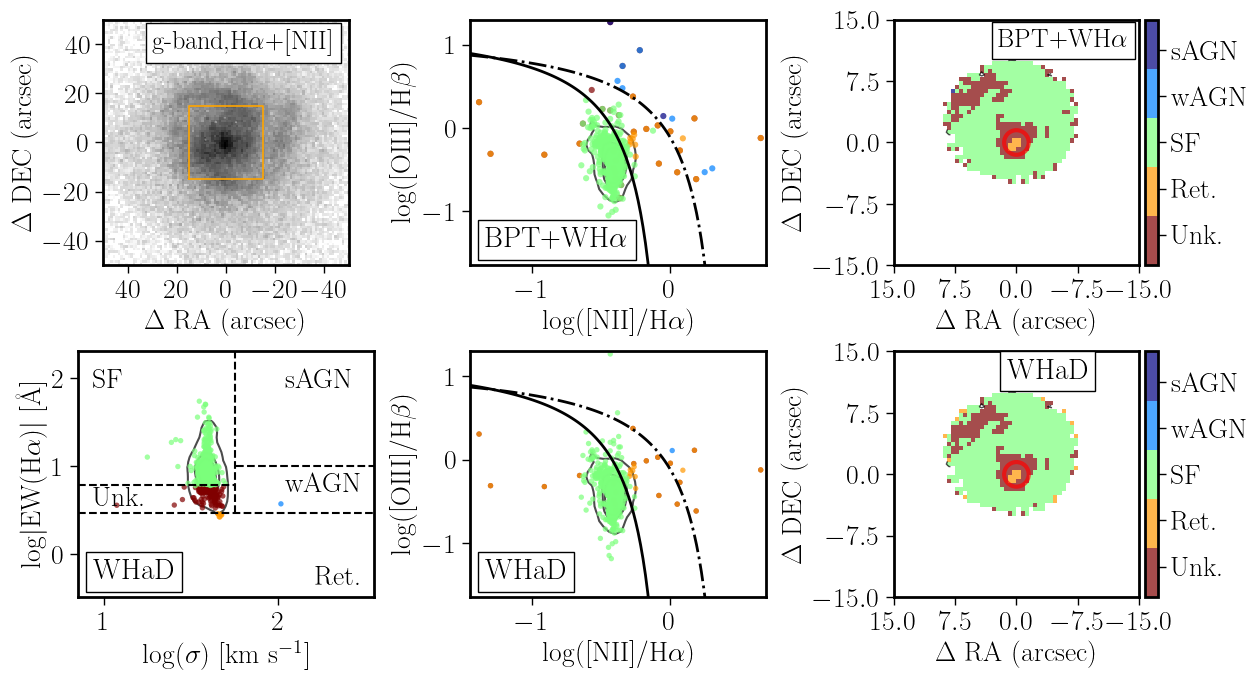

In [242]:
s_a = 1.0

fig, axes = plt.subplots(2,3, figsize=(13,7.2))
#cmap='gist_stern_r'
#cmap='plasma'
#color_cm_now = vel_map()
color_cm_now = vel_map()
reverse=0
if (reverse==1):
    color_cm_now=color_cm_now.reversed()
cmap=cm.get_cmap(color_cm_now)

cmap='jet'

indx=0
#
# Top-Left Plot
#
ax=axes[0][0]
key='DESC_'+str(indx)
val=SSP_hdr[key]
print(key,val)
image=SSP_data[indx,:,:]
image = np.ma.masked_invalid(image)
image=image*SELECT_REG_data
image=image*1.0
if ((indx!=13) and (indx!=14) and (indx!=8) and (indx!=9)):
    image=np.ma.masked_array(image,\
                             ~(image>0.0))
else:
    image=np.ma.masked_array(image,\
                             (image==0.0))
if ((indx!=0) and (indx!=3) and (indx!=4) and (indx!=12)):
    image=np.around(image,2)
vmin=np.min(image)
vmax=np.max(image)
norm=colors.PowerNorm(gamma=0.35)
image_PS= np.flipud(img_rgb)
image_PS= np.fliplr(image_PS)
nx_org=image_PS.shape[1]
ny_org=image_PS.shape[0]
img_sec = image_PS[int(nx_org/4):int(3*nx_org/4),int(ny_org/4):int(3*ny_org/4)]
nx_v23=image_PS.shape[1]*0.5
ny_v23=image_PS.shape[0]*0.5    
#ax.imshow(np.sqrt(img_sec), extent=[nx_v23/4, -nx_v23/4, -ny_v23/4, ny_v23/4],origin='lower')
ax.imshow(np.sqrt(image_PS), extent=[nx_v23, -nx_v23, -ny_v23, ny_v23],origin='lower',interpolation='none',cmap='Grays')


ax.plot([15,15,-15,-15,15],[-15,15,15,-15,-15],\
        color='orange',linestyle='-',linewidth=1.2)

#ax.patch.set_facecolor('black')
ax.set_xlabel(r'$\Delta$ RA (arcsec)')
ax.set_ylabel(r'$\Delta$ DEC (arcsec)')
    

ax.text(nx*0.6, 0.7*ny, r'g-band,H$\alpha$+[NII]', fontsize=19, bbox={'facecolor': 'white', 'pad': 5},\
        va='bottom',ha='left')

med_Ha_NII=np.median(img_Ha_NII.flat)
max_Ha_NII=np.max(img_Ha_NII.flat)

std_Ha_NII=np.std(img_Ha_NII.flat)

print(med_Ha_NII,std_Ha_NII)


levels_cont = np.log10(med_Ha_NII+0.25*std_Ha_NII)+np.abs(np.log10(std_Ha_NII))*np.arange(0,10,2)
print(10**(levels_cont))
p_cont=ax.contour(np.log10(img_Ha_NII),levels_cont,linestyles='solid',\
                      colors='white',linewidths=1.0,alpha=0.5*alpha, extent=[nx_v23/4, -nx_v23/4, -ny_v23/4, ny_v23/4],origin='lower')#,zorder=zorder)


ax.set_xticks([-40,-20,0,20,40])
ax.set_yticks([-40,-20,0,20,40])
#
# Central Plot
#
cmap_t=cm.get_cmap('jet_r', 5)#truncate_colormap(cmap, minval=0.0, maxval=1.0, n=5)



#print(cmap_t)
ax=axes[0][2]
key='DESC_'+str(indx)
val=SSP_hdr[key]
print(key,val)
image=img_diag_BPT
image = np.ma.masked_invalid(image)
image=image*SELECT_REG_data
image=image*1.0
Ha_min = med_Ha_NII+0.25*std_Ha_NII


image=np.ma.masked_array(image,\
                         (img_Ha_NII<Ha_min))
vmin=0
vmax=4#np.max(image)
norm=colors.PowerNorm(gamma=0.35)
im_now2=ax.imshow(image, interpolation='nearest',\
                 cmap=cmap_t, \
                 vmin=vmin,vmax=vmax,alpha=alpha,extent=[nx_v23/4, -nx_v23/4, -ny_v23/4, ny_v23/4],origin='lower')
cb_BPT=fig.colorbar(im_now2, ax=ax, orientation='vertical',fraction=0.044, pad=0.02)
cb_BPT.set_ticks([0.5, 1.25, 2, 2.75, 3.5])
#cb_BPT.ax.set_xticklabels(['0.5', '1.25', '2','2.75'])
cb_BPT.ax.set_yticklabels(['Unk.', 'Ret.', 'SF', 'wAGN','sAGN'])
#cb_BPT.ax.set_xticklabels(['Low', 'Medium', 'High']) 

#ax.set_xlim(0,nx)
#ax.set_ylim(0,ny)
#ax.text(0.03*nx, 0.03*ny, SSP_labels[indx], fontsize=21, bbox={'facecolor': 'white', 'pad': 5},\
#        va='bottom',ha='left')
#ax.text(0.97*nx, 0.97*ny, SSP_ulabels[indx], fontsize=21, bbox={'facecolor': 'white', 'pad': 5},\
#        va='top',ha='right')
#ax.text(0.97*nx, 0.1*ny, str(indx), fontsize=21,\
#        va='top',ha='right')
#ax.axes.get_xaxis().set_visible(False)
#ax.axes.get_yaxis().set_visible(False)

med_Ha_NII=np.median(img_Ha_NII.flat)
max_Ha_NII=np.max(img_Ha_NII.flat)

std_Ha_NII=np.std(img_Ha_NII.flat)

print(med_Ha_NII,std_Ha_NII)
#,np.std(img_Ha_NII.flat[img_Ha_NII.flat<0]))

levels_cont = np.log10(med_Ha_NII+0.25*std_Ha_NII)+np.abs(np.log10(std_Ha_NII))*np.arange(0,10,2)
#levels_cont = np.log10(med_Ha_NII+0.25*std_Ha_NII)+np.abs(np.log10(std_Ha_NII))*np.arange(0,3,0.75)
print(10**(levels_cont))
Ha_min = med_Ha_NII+0.25*std_Ha_NII
p_cont=ax.contour(np.log10(img_Ha_NII),levels_cont,linestyles='solid',\
                      colors='black',linewidths=1.0,alpha=alpha,extent=[nx_v23/4, -nx_v23/4, -ny_v23/4, ny_v23/4],origin='lower')#,zorder=zorder)               


ax.text(0.22*nx*0.2, 0.22*ny, r'BPT+WH$\alpha$', fontsize=19, bbox={'facecolor': 'white', 'pad': 5},\
        va='bottom',ha='left')

ax.set_xticks([-15,-7.5,0,7.5,15])
ax.set_yticks([-15,-7.5,0,7.5,15])#,zorder=zorder)

#ax.patch.set_facecolor('black')
ax.set_xlabel(r'$\Delta$ RA (arcsec)')
ax.set_ylabel(r'$\Delta$ DEC (arcsec)')

#
# right Plot
#
ax=axes[1][2]
key='DESC_'+str(indx)
val=SSP_hdr[key]
print(key,val)
image=img_diag_new
image = np.ma.masked_invalid(image)
image=image*SELECT_REG_data
image=image*1.0
image=np.ma.masked_array(image,\
                         (img_Ha_NII<Ha_min))
#vmin=np.min(image)
#vmax=np.max(image)
norm=colors.PowerNorm(gamma=0.35)
im_now2=ax.imshow(image, interpolation='nearest',\
                 cmap=cmap_t, \
                 vmin=vmin,vmax=vmax,alpha=alpha,extent=[nx_v23/4, -nx_v23/4, -ny_v23/4, ny_v23/4],origin='lower')
cb_BPT=fig.colorbar(im_now2, ax=ax, orientation='vertical',fraction=0.044, pad=0.02)
cb_BPT.set_ticks([0.5, 1.25, 2, 2.75, 3.5])
#cb_BPT.ax.set_xticklabels(['0.5', '1.25', '2','2.75'])
cb_BPT.ax.set_yticklabels(['Unk.', 'Ret.', 'SF', 'wAGN','sAGN'])
#cb_BPT.ax.set_xticklabels(['Low', 'Medium', 'High']) 

#ax.set_xlim(0,nx)
#ax.set_ylim(0,ny)
#ax.text(0.03*nx, 0.03*ny, SSP_labels[indx], fontsize=21, bbox={'facecolor': 'white', 'pad': 5},\
#        va='bottom',ha='left')
#ax.text(0.97*nx, 0.97*ny, SSP_ulabels[indx], fontsize=21, bbox={'facecolor': 'white', 'pad': 5},\
#        va='top',ha='right')
#ax.text(0.97*nx, 0.1*ny, str(indx), fontsize=21,\
#        va='top',ha='right')
#ax.axes.get_xaxis().set_visible(False)
#ax.axes.get_yaxis().set_visible(False)

med_Ha_NII=np.median(img_Ha_NII.flat)
max_Ha_NII=np.max(img_Ha_NII.flat)

std_Ha_NII=np.std(img_Ha_NII.flat)

print(med_Ha_NII,std_Ha_NII)
#,np.std(img_Ha_NII.flat[img_Ha_NII.flat<0]))

levels_cont = np.log10(med_Ha_NII+0.25*std_Ha_NII)+np.abs(np.log10(std_Ha_NII))*np.arange(0,10,2)
#levels_cont = np.log10(med_Ha_NII+0.25*std_Ha_NII)+np.abs(np.log10(std_Ha_NII))*np.arange(0,3,0.75)
print(10**(levels_cont))
Ha_min = med_Ha_NII+0.25*std_Ha_NII
p_cont=ax.contour(np.log10(img_Ha_NII),levels_cont,linestyles='solid',\
                      colors='black',linewidths=1.0,alpha=alpha,extent=[nx_v23/4, -nx_v23/4, -ny_v23/4, ny_v23/4],origin='lower')#,zorder=zorder)

ax.text(0.12*nx*0.2, 0.22*ny, r'WHaD', fontsize=21, bbox={'facecolor': 'white', 'pad': 5},\
        va='bottom',ha='left')
ax.set_xticks([-15,-7.5,0,7.5,15])
ax.set_yticks([-15,-7.5,0,7.5,15])#,zorder=zorder)

#ax.patch.set_facecolor('black')
ax.set_xlabel(r'$\Delta$ RA (arcsec)')
ax.set_ylabel(r'$\Delta$ DEC (arcsec)')

#
# Top-Center
#
ax=axes[0][1]
c_DL='black'
x_min=-1.45
x_max=0.7
y_min=-1.65
y_max=1.3
x=np.linspace(-1.45,0.3,100)
cut_Kau=0.61/(x-0.05)+1.3
cut_Kew=0.61/(x-0.47)+1.19
ax.plot(x[x<0],cut_Kau[x<0],'-',color=c_DL,linewidth=2)
ax.plot(x,cut_Kew,'-.',color=c_DL,linewidth=2)

ax.set_xlim(x_min,x_max)
ax.set_ylim(y_min,y_max)

x_loc=0.02
y_loc=0.02
#ax.scatter(N2[mask_SF_BPT],O3[mask_SF_BPT],c=img_diag_BPT[mask_SF_BPT],cmap=cmap_t,alpha=alpha,edgecolor='None',s=10)
hex_c=[]
for i in range(cmap_t.N):
    rgb = cmap_t(i)[:3]  # will return rgba, we take only first 3 so we get rgb
    hex_c.append(matplotlib.colors.rgb2hex(rgb))

spx=20

my_contour(ax,N2,O3,\
                   x_min,x_max,y_min,y_max,c_color='black',\
            nbins=50,title='',linewidths=1.5,alpha=0.7)



ax.scatter(N2[~mask_BPT],O3[~mask_BPT],color=hex_c[0],alpha=s_a*alpha,edgecolor='None',s=spx,label='Unk',rasterized=True)
ax.scatter(N2[mask_RG_BPT],O3[mask_RG_BPT],color=hex_c[1],alpha=s_a*alpha,edgecolor='None',s=spx,label='Ret.',rasterized=True)
ax.scatter(N2[mask_SF_BPT],O3[mask_SF_BPT],color=hex_c[2],alpha=s_a*alpha,edgecolor='None',s=spx,label='SF',rasterized=True)
ax.scatter(N2[mask_wAGN_BPT],O3[mask_wAGN_BPT],color=hex_c[3],alpha=s_a*alpha,edgecolor='None',s=spx,label='wAGN',rasterized=True)
ax.scatter(N2[mask_sAGN_BPT],O3[mask_sAGN_BPT],color=hex_c[4],alpha=s_a*alpha,edgecolor='None',s=spx,label='sAGN',rasterized=True)




ax.text(x_min+0.05*(x_max-x_min), y_min+0.05*(y_max-y_min), r'BPT+WH$\alpha$', fontsize=21, bbox={'facecolor': 'white', 'pad': 5},\
        va='bottom',ha='left')

#handles, labels = ax.get_legend_handles_labels()
#ax.legend(handles, labels,loc=(x_loc,y_loc),frameon=True,\
#          handlelength=0.85,ncol=3,columnspacing=0.05,edgecolor='black',fontsize=18)
ax.set_xlabel(r'log([NII]/H$\alpha$)')
ax.set_ylabel(r'log([OIII]/H$\beta$)')
#plt.tight_layout()


#
# Bottom-Center
#
ax=axes[1][1]
c_DL='black'
x_min=-1.45
x_max=0.7
y_min=-1.65
y_max=1.3
x=np.linspace(-1.45,0.3,100)
cut_Kau=0.61/(x-0.05)+1.3
cut_Kew=0.61/(x-0.47)+1.19
ax.plot(x[x<0],cut_Kau[x<0],'-',color=c_DL,linewidth=2)
ax.plot(x,cut_Kew,'-.',color=c_DL,linewidth=2)

ax.set_xlim(x_min,x_max)
ax.set_ylim(y_min,y_max)

x_loc=0.02
y_loc=0.02
#ax.scatter(N2[mask_SF_BPT],O3[mask_SF_BPT],c=img_diag_BPT[mask_SF_BPT],cmap=cmap_t,alpha=alpha,edgecolor='None',s=10)
hex_c=[]
for i in range(cmap_t.N):
    rgb = cmap_t(i)[:3]  # will return rgba, we take only first 3 so we get rgb
    hex_c.append(matplotlib.colors.rgb2hex(rgb))

spx=15

my_contour(ax,N2,O3,\
                   x_min,x_max,y_min,y_max,c_color='black',\
            nbins=50,title='',linewidths=1.5,alpha=0.7)
ax.scatter(N2[~mask_ND],O3[~mask_ND],color=hex_c[0],alpha=s_a*alpha,edgecolor='None',s=spx,label='Unk',rasterized=True)
ax.scatter(N2[mask_RG_new],O3[mask_RG_new],color=hex_c[1],alpha=s_a*alpha,edgecolor='None',s=spx,label='Ret.',rasterized=True)
ax.scatter(N2[mask_SF_new],O3[mask_SF_new],color=hex_c[2],alpha=s_a*alpha,edgecolor='None',s=spx,label='SF',rasterized=True)
ax.scatter(N2[mask_wAGN_new],O3[mask_wAGN_new],color=hex_c[3],alpha=s_a*alpha,edgecolor='None',s=spx,label='wAGN',rasterized=True)
ax.scatter(N2[mask_sAGN_new],O3[mask_sAGN_new],color=hex_c[4],alpha=s_a*alpha,edgecolor='None',s=spx,label='sAGN',rasterized=True)
ax.text(x_min+0.05*(x_max-x_min), y_min+0.05*(y_max-y_min), r'WHaD', fontsize=21, bbox={'facecolor': 'white', 'pad': 5},\
        va='bottom',ha='left')

#handles, labels = ax.get_legend_handles_labels()
#ax.legend(handles, labels,loc=(x_loc,y_loc),frameon=True,\
#          handlelength=0.85,ncol=3,columnspacing=0.05,edgecolor='black',fontsize=18)
ax.set_xlabel(r'log([NII]/H$\alpha$)')
ax.set_ylabel(r'log([OIII]/H$\beta$)')
#plt.tight_layout()

#ax.set_aspect('square')

#
# Bottom-left
#
ax=axes[1][0]

x_min=0.85
x_max=2.55
y_min=-0.49
y_max=2.3
lEW_cut=np.arange(0.78,1.3,0.5)
lsigma_cut=(lEW_cut+5)/3-0.243
#lsigma_cut=np.arange(1.75,2.3,0.1)
#lEW_cut =-5+3*lsigma_cut
#ax.plot(lsigma_cut,lEW_cut,'--',c='black')
ax.plot([x_min,1.75],[0.78,0.78],'--',c='black')
ax.plot([1.75,1.75],[0.47,y_max],'--',c='black')

#ax.plot([2.1-0.243,2.1-0.243],[lEW_cut[-1],2.2],'--',c='black')
ax.plot([x_min,x_max],[0.47,0.47],'--',c='black')
ax.plot([2-0.243,x_max],[1.0,1.0],'--',c='black')

X=np.log10(img_disp_kms)
Y=np.log10(np.abs(img_WHa))

my_contour(ax,X,Y,\
                   x_min,x_max,y_min,y_max,c_color='black',\
            nbins=50,title='',linewidths=1.5,alpha=0.7)

ax.scatter(X[mask_UK_new],Y[mask_UK_new],color=hex_c[0],alpha=s_a*alpha,edgecolor='None',s=spx,label='Unk',rasterized=True)
ax.scatter(X[mask_RG_new],Y[mask_RG_new],color=hex_c[1],alpha=s_a*alpha,edgecolor='None',s=spx,label='Ret.',rasterized=True)
ax.scatter(X[mask_SF_new],Y[mask_SF_new],color=hex_c[2],alpha=s_a*alpha,edgecolor='None',s=spx,label='SF',rasterized=True)
ax.scatter(X[mask_wAGN_new],Y[mask_wAGN_new],color=hex_c[3],alpha=s_a*alpha,edgecolor='None',s=spx,label='wAGN',rasterized=True)
ax.scatter(X[mask_sAGN_new],Y[mask_sAGN_new],color=hex_c[4],alpha=s_a*alpha,edgecolor='None',s=spx,label='sAGN',rasterized=True)




ax.text(x_max-0.2*np.abs(x_max-x_min),y_min+0.05*np.abs(y_max-y_min),'Ret.')
ax.text(x_min+0.05*np.abs(x_max-x_min),y_max-0.15*np.abs(y_max-y_min),'SF')
ax.text(x_min+0.05*np.abs(x_max-x_min),0.55,'Unk.')
ax.text(x_max-0.3*np.abs(x_max-x_min),y_max-0.15*np.abs(y_max-y_min),'sAGN')
ax.text(x_max-0.3*np.abs(x_max-x_min),0.7,'wAGN')


#ax.set_xlim(1.81,2.75)
#ax.set_xlim(1.5,2.5)
#ax.set_ylim(-0.49,2.1)
ax.set_xlim(x_min,x_max)
ax.set_ylim(y_min,y_max)

ax.text(x_min+0.05*(x_max-x_min), y_min+0.05*(y_max-y_min), r'WHaD', fontsize=21, bbox={'facecolor': 'white', 'pad': 5},\
        va='bottom',ha='left')

ax.set_xlabel(r'log($\sigma$) [km s$^{-1}$]')
ax.set_ylabel(r'log$|$EW(H$\alpha$)$|$ [${\rm \AA}$]')

mask_name = tab['name']==name_gal
XC=0
YC=0
#tab['YC'].value[mask_name]-ny/2
print(XC,YC)

circle=matplotlib.patches.Circle((XC,YC), 1.5, ec="none")
circle.set(color='None',edgecolor='red',linewidth=3,alpha=0.7)
ax=axes[0,2]
ax.add_artist(circle)
circle=matplotlib.patches.Circle((XC,YC), 1.5, ec="none")
circle.set(color='None',edgecolor='red',linewidth=3,alpha=0.7)
ax=axes[1,2]
ax.add_artist(circle)
#ax=axes[1,2]
#ax.add_artist(circle)


fig.tight_layout(w_pad=0.3,h_pad=0.2)

#fig.tight_layout(w_pad=0.2,h_pad=0.15)

#fig.tight_layout(w_pad=0.2,h_pad=0.15)

figname=name_gal+'_diag.pdf'
fig.savefig('fig_diag/'+figname, transparent=False, facecolor='white', edgecolor='white')#.pdf")

#    SSP_maps[val]=SSP_data[i,:,:]
#print(SSP_maps['pseudo V-band map'])

#print(nx)

In [195]:
#img_disp_masked = img_disp_kms.copy()
#img_disp_masked[img_disp_kms<10**(1.6)]=0
#img=plt.imshow(img_disp_masked,origin='lower')
#plt.colorbar(img)

In [66]:
#img=plt.imshow(img_disp,origin='lower')
#plt.colorbar(img)

In [67]:
for i in range(cmap_t.N):
    rgb = cmap_t(i)[:3]  # will return rgba, we take only first 3 so we get rgb
    print(matplotlib.colors.rgb2hex(rgb))

#800000
#ff9700
#7bff7b
#0080ff
#000080
